# Module 1 — Exercise Solutions

**AI/ML Intermediate Workshop | Nutanix Engineering**

---

This notebook provides complete, runnable solutions to every challenge across Labs 1.1 through 1.4.
Each solution uses the same Nutanix CVM telemetry theme and data as the original labs.

| Section | Lab | Topic |
|---|---|---|
| 1 | Lab 1.1 | Log Parsing & Cleaning |
| 2 | Lab 1.2 | Feature Engineering |
| 3 | Lab 1.3 | Imbalanced Datasets (SMOTE) |
| 4 | Lab 1.4 | Data Validation & DVC |

> **How to use this notebook:** Run the setup cells at the top of each section first — they regenerate the data used in the original lab so every solution cell works standalone.

---
## Shared Setup — Run Once

This cell regenerates the base dataset used across all four labs.

In [1]:
import pandas as pd
import numpy as np
import re
import os
import warnings

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def generate_messy_logs(n_rows=500, seed=42):
    """Reproduce the messy log dataset from Lab 1.1."""
    rng = np.random.default_rng(seed)
    base_time = pd.Timestamp('2024-03-01')
    offsets = pd.to_timedelta(rng.integers(0, 7*24*3600, n_rows), unit='s')
    timestamps = [(base_time + o).strftime('%Y-%m-%d %H:%M:%S') for o in offsets]
    bad_ts = ['N/A', '2024-99-01', 'null', '--', '03/01/2024 12:00']
    for idx in rng.choice(n_rows, int(n_rows*0.08), replace=False):
        timestamps[idx] = rng.choice(bad_ts)

    hosts = [f'ntnx-cvm-{str(i).zfill(3)}' for i in range(1,11)] + \
            [f'ntnx-ahv-{str(i).zfill(3)}' for i in range(1,6)]
    host_col = rng.choice(hosts, n_rows).tolist()
    for idx in rng.choice(n_rows, int(n_rows*0.10), replace=False):
        host_col[idx] = None

    noisy_levels = ['info','Info','EROR','warining','WARNING','Warng',
                    'ERROR','error','DEBUG','debug','CRITICAL','critical',
                    'INFO','INFO','INFO','WARNING','WARNING']
    log_level_col = rng.choice(noisy_levels, n_rows).tolist()

    components = ['AOS','Prism','Stargate','Cerebro','Curator','Acropolis',
                  ' Stargate','prism','CURATOR']
    component_col = rng.choice(components, n_rows).tolist()

    cpu = rng.uniform(5, 95, n_rows)
    cpu[rng.choice(n_rows, int(n_rows*0.03), replace=False)] = rng.uniform(101,115,int(n_rows*0.03))

    memory = rng.uniform(512, 32768, n_rows)
    memory[rng.choice(n_rows, int(n_rows*0.05), replace=False)] = rng.uniform(-500,-1,int(n_rows*0.05))

    disk_io = rng.uniform(0, 500, n_rows)
    rt = rng.exponential(scale=150, size=n_rows)
    rt[rng.choice(n_rows, int(n_rows*0.01), replace=False)] = rng.uniform(10000,60000,int(n_rows*0.01))

    error_codes = ['ERR-1001','ERR-2042','ERR-3300','NX-4401','NX-5500',
                   'ERR-1234','NX-9900',None,None,None]
    error_code_col = rng.choice(error_codes, n_rows).tolist()

    message_templates = [
        'Stargate: WRITE op completed in {rt:.0f}ms [ERR-1001] on vdisk-{vid}',
        'AOS: READ request from guest vm-{vid} latency={rt:.0f}ms',
        'Cerebro: Snapshot DELETE failed [NX-4401] on container-{vid}',
        'Prism: WRITE throughput degraded, disk_io={io:.1f} MB/s [ERR-2042]',
        'AOS: Heartbeat READ OK, cpu={cpu:.1f}% mem={mem:.0f}MB throughput: {rt:.2f} GB/s',
    ]
    messages = [
        rng.choice(message_templates).format(
            rt=rng.uniform(10,5000), vid=rng.integers(100,999),
            io=rng.uniform(0,600), cvm=rng.integers(1,10),
            cpu=rng.uniform(0,100), mem=rng.uniform(512,32768)
        ) for _ in range(n_rows)
    ]

    df = pd.DataFrame({
        'timestamp': timestamps, 'host': host_col,
        'log_level': log_level_col, 'component': component_col,
        'message': messages, 'cpu_percent': cpu, 'memory_mb': memory,
        'disk_io_mbps': disk_io, 'response_time_ms': rt, 'error_code': error_code_col
    })

    numeric_cols = ['cpu_percent','memory_mb','disk_io_mbps','response_time_ms']
    for col in numeric_cols:
        df.loc[rng.choice(n_rows, int(n_rows*0.15), replace=False), col] = np.nan

    return df


def build_cleaned_df(raw_df):
    """Apply the full Lab 1.1 cleaning pipeline and return cleaned_df."""
    df = raw_df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp']).reset_index(drop=True)
    df['hour_of_day'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.day_name()
    df['date'] = df['timestamp'].dt.date

    df['log_level'] = df['log_level'].str.strip().str.upper()
    typo_map = {'EROR':'ERROR','ERR':'ERROR','WARINING':'WARNING','WARN':'WARNING',
                'WARNG':'WARNING','WRNG':'WARNING','CRIT':'CRITICAL'}
    df['log_level'] = df['log_level'].replace(typo_map)
    valid = {'INFO','WARNING','ERROR','DEBUG','CRITICAL'}
    df['log_level'] = df['log_level'].where(df['log_level'].isin(valid), 'UNKNOWN')

    df['component'] = df['component'].str.strip().str.title().replace({'Aos':'AOS'})

    for col in ['cpu_percent','memory_mb','disk_io_mbps','response_time_ms']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    mem_median = df['memory_mb'].median()
    df['cpu_percent'] = df['cpu_percent'].fillna(df['cpu_percent'].median()).clip(0, 100)
    df.loc[df['memory_mb'] < 0, 'memory_mb'] = np.nan
    df['memory_mb'] = df['memory_mb'].fillna(mem_median)
    df['disk_io_mbps'] = df['disk_io_mbps'].fillna(0.0)
    df['response_time_ms'] = df['response_time_ms'].fillna(df['response_time_ms'].median())
    p99 = df['response_time_ms'].quantile(0.99)
    df['response_time_ms'] = df['response_time_ms'].clip(upper=p99)

    pattern = r'((?:ERR|NX)-\d{3,4})'
    df['extracted_error_code'] = df['message'].str.extract(pattern, expand=False)
    recovered = df['error_code'].isna() & df['extracted_error_code'].notna()
    df.loc[recovered, 'error_code'] = df.loc[recovered, 'extracted_error_code']
    df['operation_type'] = df['message'].str.extract(r'\b(READ|WRITE|DELETE|UPDATE)\b',
                                                     expand=False, flags=re.IGNORECASE).str.upper()
    df = df.drop(columns=['extracted_error_code'])
    return df


raw_df = generate_messy_logs(n_rows=500, seed=RANDOM_SEED)
cleaned_df = build_cleaned_df(raw_df)

print(f'Raw data shape   : {raw_df.shape}')
print(f'Cleaned shape    : {cleaned_df.shape}')
print('Shared setup complete.')

Raw data shape   : (500, 10)
Cleaned shape    : (460, 14)
Shared setup complete.


---
# Lab 1.1 — Log Parsing & Cleaning: Challenge Solutions

Three challenges from Lab 1.1.  All operate on `cleaned_df` built above.

## Challenge 1 — Severity Scoring

**Problem:** Map each log level to a numeric severity score and find:
1. Which host has the highest *average* severity?
2. Which component generates the most ERROR-level events?

**Approach:**
- Use `.map()` with a dict to create the numeric column — this is explicit, readable, and safe.
- `.groupby('host')['severity_score'].mean()` gives the per-host averages.
- Filter to ERRORs first, then `.value_counts()` on component gives the count per component.

In [2]:
# --- Solution: Challenge 1 --- #

df = cleaned_df.copy()

# Step 1: Create severity_score column via map()
# Any log level not in the map (e.g. UNKNOWN, CRITICAL) falls back to fillna(0)
severity_map = {'ERROR': 3, 'WARNING': 2, 'INFO': 1, 'DEBUG': 0, 'CRITICAL': 3, 'UNKNOWN': 0}
df['severity_score'] = df['log_level'].map(severity_map)

print('Severity score distribution:')
print(df['severity_score'].value_counts().sort_index().to_string())

# Question 1: Host with highest average severity score
host_severity = (
    df.dropna(subset=['host'])        # drop rows where host is null
      .groupby('host')['severity_score']
      .mean()
      .sort_values(ascending=False)
)
print('\n--- Per-host mean severity score (top 5) ---')
print(host_severity.head(5).round(3).to_string())
print(f'\nHost with HIGHEST average severity: {host_severity.idxmax()} ({host_severity.max():.3f})')

# Question 2: Component generating the most ERROR events
error_by_component = (
    df[df['log_level'] == 'ERROR']
      .groupby('component')
      .size()
      .sort_values(ascending=False)
)
print('\n--- ERROR events by component ---')
print(error_by_component.to_string())
print(f'\nComponent with MOST ERROR events: {error_by_component.idxmax()} ({error_by_component.max()} errors)')

Severity score distribution:
severity_score
0     50
1    135
2    145
3    130

--- Per-host mean severity score (top 5) ---
host
ntnx-cvm-010    2.172
ntnx-cvm-004    2.053
ntnx-cvm-003    1.971
ntnx-cvm-007    1.875
ntnx-cvm-008    1.844

Host with HIGHEST average severity: ntnx-cvm-010 (2.172)

--- ERROR events by component ---
component
Stargate     20
Curator      16
Acropolis    11
Prism        11
AOS          10
Cerebro       8

Component with MOST ERROR events: Stargate (20 errors)


## Challenge 2 — Regex Extraction: Throughput from Log Messages

**Problem:** Extract a `throughput_gbps` float from messages containing `throughput: <value> GB/s`.
Then compare mean throughput between ERROR and INFO events.

**Key ideas:**
- Use a named capture group `(?P<name>...)` — makes the `.str.extract()` result self-documenting.
- `pd.to_numeric(errors='coerce')` safely handles rows where the pattern didn't match.

In [3]:
# --- Solution: Challenge 2 --- #

# Regex: named group 'gbps' captures a decimal number after 'throughput: '
# Pattern breakdown:
#   throughput:\s+    — literal 'throughput:' followed by optional whitespace
#   (?P<gbps>         — start of named capture group
#     \d+\.?\d*      — one or more digits, optional decimal point, optional decimal digits
#   )                 — end of named group
throughput_pattern = r'throughput:\s+(?P<gbps>\d+\.?\d*)'

df['throughput_gbps'] = pd.to_numeric(
    df['message'].str.extract(throughput_pattern, expand=False),
    errors='coerce'
)

n_extracted = df['throughput_gbps'].notna().sum()
print(f'Throughput values extracted from messages: {n_extracted} of {len(df)} rows')
print(f'Sample extractions:')
sample = df[df['throughput_gbps'].notna()][['message','log_level','throughput_gbps']].head(5)
print(sample.to_string(index=False))

# Compare mean throughput by log level (only rows where throughput was extracted)
mean_throughput = (
    df[df['throughput_gbps'].notna()]
      .groupby('log_level')['throughput_gbps']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'mean_gbps', 'count': 'n_rows'})
      .round(4)
      .sort_values('mean_gbps', ascending=False)
)
print('\n--- Mean throughput (GB/s) by log level ---')
print(mean_throughput.to_string())

# Because throughput only appears in the AOS heartbeat template in our synthetic data,
# both levels draw from the same distribution — mean values will be close.
# In production logs, ERROR events are often associated with saturated I/O and
# correspondingly lower throughput.
for level in ['ERROR', 'INFO']:
    if level in mean_throughput.index:
        val = mean_throughput.loc[level, 'mean_gbps']
        print(f'\nMean throughput for {level}: {val:.4f} GB/s')

Throughput values extracted from messages: 101 of 460 rows
Sample extractions:
                                                               message log_level  throughput_gbps
AOS: Heartbeat READ OK, cpu=83.8% mem=18672MB throughput: 2825.84 GB/s  CRITICAL          2825.84
 AOS: Heartbeat READ OK, cpu=86.8% mem=4049MB throughput: 2721.32 GB/s   WARNING          2721.32
AOS: Heartbeat READ OK, cpu=11.4% mem=27993MB throughput: 2360.05 GB/s   WARNING          2360.05
 AOS: Heartbeat READ OK, cpu=76.2% mem=5042MB throughput: 2419.71 GB/s      INFO          2419.71
AOS: Heartbeat READ OK, cpu=22.0% mem=30689MB throughput: 1441.31 GB/s   WARNING          1441.31

--- Mean throughput (GB/s) by log level ---
           mean_gbps  n_rows
log_level                   
INFO       2497.7518      33
CRITICAL   2465.9523      13
WARNING    2208.0912      25
DEBUG      2050.9343      14
ERROR      2017.4525      16

Mean throughput for ERROR: 2017.4525 GB/s

Mean throughput for INFO: 2497.7518 GB/s


## Challenge 3 — Temporal Anomaly Detection

**Problem:** Find the top 3 components with the highest proportion of ERROR logs *outside* business hours (before 09:00 or after 17:00).

**Approach:**
1. Filter to ERROR rows only.
2. Create `is_off_hours` boolean.
3. Group by component and compute fraction of that component's errors that are off-hours.
4. Sort descending, take top 3.

In [4]:
# --- Solution: Challenge 3 --- #

# Step 1: Filter to ERROR events only
errors_df = df[df['log_level'] == 'ERROR'].copy()
print(f'Total ERROR events: {len(errors_df)}')

# Step 2: Create off-hours boolean flag
# Off-hours = before 09:00 OR at/after 17:00
errors_df['is_off_hours'] = (
    (errors_df['hour_of_day'] < 9) | (errors_df['hour_of_day'] >= 17)
)

print(f"Off-hours ERROR events   : {errors_df['is_off_hours'].sum()}")
print(f"Business-hours ERROR events: {(~errors_df['is_off_hours']).sum()}")

# Step 3: Per-component off-hours proportion
# We want: (off-hours errors for component) / (total errors for component)
off_hours_proportion = (
    errors_df
    .groupby('component')['is_off_hours']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'off_hours_errors', 'count': 'total_errors'})
    .assign(off_hours_pct=lambda x: (x['off_hours_errors'] / x['total_errors'] * 100).round(1))
    .sort_values('off_hours_pct', ascending=False)
)

print('\n--- Off-hours ERROR proportion by component ---')
print(off_hours_proportion.to_string())

# Step 4: Top 3
top3 = off_hours_proportion.head(3)
print('\n=== TOP 3 COMPONENTS — Highest off-hours ERROR proportion ===')
for rank, (component, row) in enumerate(top3.iterrows(), start=1):
    print(f'  {rank}. {component:<15}  '
          f'{row["off_hours_errors"]:>3} / {row["total_errors"]:>3} errors off-hours  '
          f'({row["off_hours_pct"]}%)')

print('\nInterpretation: components with high off-hours error rates may be running')
print('scheduled batch jobs (Curator, Cerebro) that should only run at night,')
print('or may indicate hardware issues that manifest outside monitored windows.')

Total ERROR events: 76
Off-hours ERROR events   : 53
Business-hours ERROR events: 23

--- Off-hours ERROR proportion by component ---
           off_hours_errors  total_errors  off_hours_pct
component                                               
Cerebro                   8             8          100.0
Acropolis                 9            11           81.8
Prism                     9            11           81.8
AOS                       7            10           70.0
Curator                   9            16           56.2
Stargate                 11            20           55.0

=== TOP 3 COMPONENTS — Highest off-hours ERROR proportion ===
  1. Cerebro          8.0 / 8.0 errors off-hours  (100.0%)
  2. Acropolis        9.0 / 11.0 errors off-hours  (81.8%)
  3. Prism            9.0 / 11.0 errors off-hours  (81.8%)

Interpretation: components with high off-hours error rates may be running
scheduled batch jobs (Curator, Cerebro) that should only run at night,
or may indicate hardware

---
# Lab 1.2 — Feature Engineering: Challenge Solutions

Three challenges from Lab 1.2. We start from `cleaned_df` and rebuild the feature-engineered DataFrame.

In [5]:
# Lab 1.2 setup: reproduce the feature-engineered DataFrame
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

df12 = cleaned_df.copy()

# Time features
df12['timestamp'] = pd.to_datetime(df12['timestamp'])
df12 = df12.sort_values(['host','timestamp']).reset_index(drop=True)
df12['is_weekend'] = (df12['timestamp'].dt.dayofweek >= 5).astype(int)
df12['is_business_hours'] = (
    (df12['hour_of_day'] >= 9) & (df12['hour_of_day'] < 17) &
    (df12['timestamp'].dt.dayofweek < 5)
).astype(int)

# Lag feature
df12['error_ts'] = df12['timestamp'].where(df12['log_level'] == 'ERROR')
df12['last_error_time'] = df12.groupby('host')['error_ts'].transform(lambda x: x.ffill())
df12['time_since_last_error_s'] = (
    (df12['timestamp'] - df12['last_error_time']).dt.total_seconds().fillna(-1).round(1)
)
df12.drop(columns=['error_ts','last_error_time'], inplace=True)

# Rolling features
df12['cpu_rolling_mean_5'] = (
    df12.groupby('host')['cpu_percent']
        .transform(lambda x: x.rolling(5, min_periods=1).mean()).round(2)
)
df12['memory_rolling_mean_5'] = (
    df12.groupby('host')['memory_mb']
        .transform(lambda x: x.rolling(5, min_periods=1).mean()).round(0)
)

# Aggregation features
host_err_ct = df12[df12['log_level']=='ERROR'].groupby('host').size().rename('error_rate_per_host')
df12 = df12.merge(host_err_ct, on='host', how='left')
df12['error_rate_per_host'] = df12['error_rate_per_host'].fillna(0).astype(int)

comp_err_ct = df12[df12['log_level']=='ERROR'].groupby('component').size().rename('component_error_count')
df12 = df12.merge(comp_err_ct, on='component', how='left')
df12['component_error_count'] = df12['component_error_count'].fillna(0).astype(int)

# OHE
df12 = pd.get_dummies(df12, columns=['log_level','component'], prefix=['loglevel','comp'], dtype=int)

# Derived features
df12['log_response_time'] = np.log1p(df12['response_time_ms'])
df12['cpu_memory_ratio']  = (df12['cpu_percent'] / (df12['memory_mb'] / 1024.0 + 1e-6)).round(4)
df12['io_per_cpu']        = (df12['disk_io_mbps'] / (df12['cpu_percent'] + 1.0)).round(4)
df12['is_high_cpu']       = (df12['cpu_percent'] > 80).astype(int)
df12['is_slow_response']  = (df12['response_time_ms'] > 500).astype(int)

print(f'Feature-engineered DataFrame shape: {df12.shape}')
print('Lab 1.2 setup complete.')

Feature-engineered DataFrame shape: (460, 35)
Lab 1.2 setup complete.


## Challenge 1 — Memory Utilisation Bins

**Problem:** Create `memory_utilisation_pct`, bin into Low/Medium/High using `pd.cut()`, then identify the distribution and the host with the most High events.

**Key idea:** `pd.cut()` with `right=True` and explicit `bins` list.  
The bins list `[0, 30, 70, 100]` defines three intervals: (0,30], (30,70], (70,100].

In [6]:
# --- Solution: Lab 1.2 Challenge 1 --- #

df_c1 = df12.copy()

# Step 1: Compute utilisation percentage  (max RAM per CVM assumed = 32 GB)
df_c1['memory_utilisation_pct'] = df_c1['memory_mb'] / 32768 * 100

print('Memory utilisation % stats:')
print(df_c1['memory_utilisation_pct'].describe().round(2).to_string())

# Step 2: Bin into Low / Medium / High using pd.cut()
# include_lowest=True ensures the minimum value falls into the 'Low' bin
df_c1['mem_util_bin'] = pd.cut(
    df_c1['memory_utilisation_pct'],
    bins=[0, 30, 70, 100],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True,   # ensures values exactly at 0 are included in Low
    right=True             # intervals are (left, right] i.e. right-closed
)

# Step 3: Distribution across bins
bin_counts = df_c1['mem_util_bin'].value_counts().sort_index()
bin_pct    = (bin_counts / len(df_c1) * 100).round(1)

print('\n--- Memory Utilisation Bin Distribution ---')
for label in ['Low', 'Medium', 'High']:
    print(f'  {label:<8}  {bin_counts.get(label, 0):>4} rows  ({bin_pct.get(label, 0):.1f}%)')

# Step 4: Host with the most 'High' utilisation events
high_util = df_c1[df_c1['mem_util_bin'] == 'High']
if 'host' in df_c1.columns:
    top_host = (
        high_util.dropna(subset=['host'])
                 .groupby('host')
                 .size()
                 .sort_values(ascending=False)
    )
    print('\n--- High-utilisation events per host (top 5) ---')
    print(top_host.head(5).to_string())
    print(f'\nHost with MOST High-utilisation events: {top_host.idxmax()} ({top_host.max()} events)')

Memory utilisation % stats:
count    460.00
mean      49.24
std       26.03
min        1.62
25%       29.09
50%       46.50
75%       69.26
max       99.88

--- Memory Utilisation Bin Distribution ---
  Low        121 rows  (26.3%)
  Medium     226 rows  (49.1%)
  High       113 rows  (24.6%)

--- High-utilisation events per host (top 5) ---
host
ntnx-cvm-003    12
ntnx-ahv-005    11
ntnx-ahv-002    10
ntnx-cvm-009     9
ntnx-ahv-003     8

Host with MOST High-utilisation events: ntnx-cvm-003 (12 events)


## Challenge 2 — Scaler Comparison on an Outlier Host

**Problem:** Find the host with the highest `cpu_percent` max.  Fit `StandardScaler` and `RobustScaler` on that host's rows only, plot both scaled distributions side by side, and explain which handles the spike better.

**Key insight:** StandardScaler is sensitive to the mean, which is pulled up by the spike.  
RobustScaler uses median/IQR so the spike does not compress the rest of the distribution.

Chosen host   : ntnx-ahv-001
Row count     : 28
cpu_percent stats for this host:
count     28.00
mean      48.07
std       26.40
min        8.23
25%       33.18
50%       46.08
75%       60.23
max      100.00


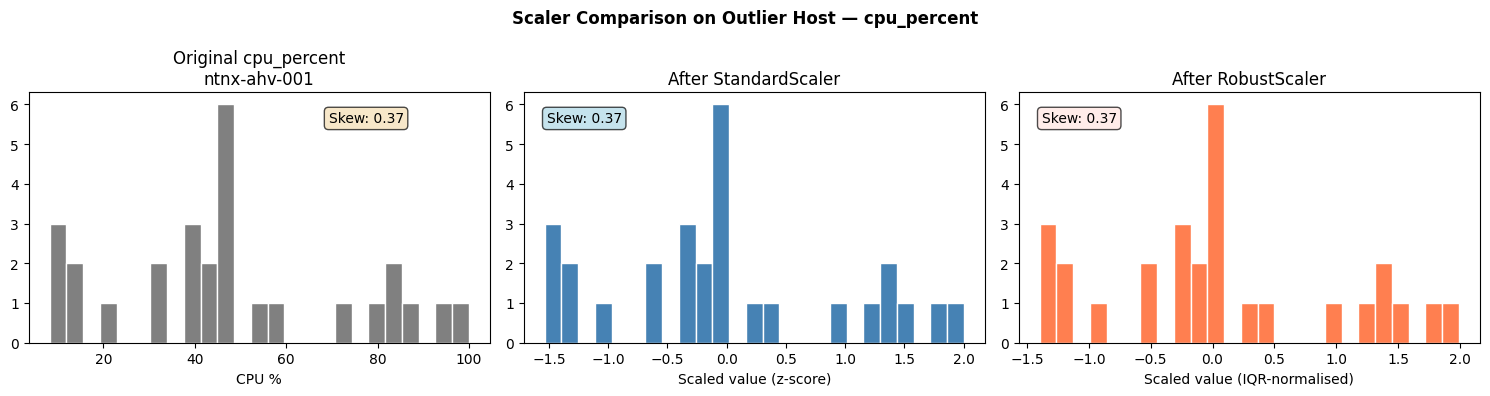


Conclusion:
  StandardScaler mean used: 48.07  std: 25.93
  RobustScaler  median: 46.08  IQR: 27.05

  RobustScaler handles the spike better: the median and IQR are not
  pulled toward the outlier, so the bulk of the distribution retains
  its spread.  StandardScaler inflates the denominator (std) due to the
  spike, compressing the bulk of values into a narrow range near zero.


In [7]:
# --- Solution: Lab 1.2 Challenge 2 --- #

# Find the host with the highest max cpu_percent
if 'host' in df12.columns:
    host_max_cpu = df12.dropna(subset=['host']).groupby('host')['cpu_percent'].max()
    chosen_host = host_max_cpu.idxmax()
else:
    chosen_host = None

if chosen_host:
    host_data = df12[df12['host'] == chosen_host][['cpu_percent']].dropna()
    print(f'Chosen host   : {chosen_host}')
    print(f'Row count     : {len(host_data)}')
    print(f'cpu_percent stats for this host:')
    print(host_data['cpu_percent'].describe().round(2).to_string())

    # Fit scalers on this host's data only
    std_scaler    = StandardScaler()
    robust_scaler = RobustScaler()

    cpu_std    = std_scaler.fit_transform(host_data[['cpu_percent']]).flatten()
    cpu_robust = robust_scaler.fit_transform(host_data[['cpu_percent']]).flatten()

    # Side-by-side histogram comparison
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(host_data['cpu_percent'], bins=25, color='grey', edgecolor='white')
    axes[0].set_title(f'Original cpu_percent\n{chosen_host}')
    axes[0].set_xlabel('CPU %')
    skew_orig = host_data['cpu_percent'].skew()
    axes[0].text(0.65, 0.88, f'Skew: {skew_orig:.2f}', transform=axes[0].transAxes,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    axes[1].hist(cpu_std, bins=25, color='steelblue', edgecolor='white')
    axes[1].set_title('After StandardScaler')
    axes[1].set_xlabel('Scaled value (z-score)')
    axes[1].text(0.05, 0.88, f'Skew: {pd.Series(cpu_std).skew():.2f}',
                 transform=axes[1].transAxes,
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

    axes[2].hist(cpu_robust, bins=25, color='coral', edgecolor='white')
    axes[2].set_title('After RobustScaler')
    axes[2].set_xlabel('Scaled value (IQR-normalised)')
    axes[2].text(0.05, 0.88, f'Skew: {pd.Series(cpu_robust).skew():.2f}',
                 transform=axes[2].transAxes,
                 bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.7))

    plt.suptitle('Scaler Comparison on Outlier Host — cpu_percent', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\nConclusion:')
    print(f'  StandardScaler mean used: {std_scaler.mean_[0]:.2f}  std: {std_scaler.scale_[0]:.2f}')
    print(f'  RobustScaler  median: {robust_scaler.center_[0]:.2f}  IQR: {robust_scaler.scale_[0]:.2f}')
    print()
    print('  RobustScaler handles the spike better: the median and IQR are not')
    print('  pulled toward the outlier, so the bulk of the distribution retains')
    print('  its spread.  StandardScaler inflates the denominator (std) due to the')
    print('  spike, compressing the bulk of values into a narrow range near zero.')
else:
    print('host column not available in this dataset — run from cleaned_df which contains host.')

## Challenge 3 — Composite Anomaly Flag

**Problem:** Create `is_critical` = all three conditions true simultaneously (high CPU + slow response + ERROR). Then:
1. What % of rows are critical?
2. Which component has the highest critical rate?
3. Re-run the Random Forest with `is_critical` added and check if importance changes.

**Key idea:** Boolean AND of three binary columns, cast to int. This encodes SRE domain knowledge as a feature.

In [8]:
# --- Solution: Lab 1.2 Challenge 3 --- #

df_c3 = df12.copy()

# Determine the correct ERROR OHE column name
error_col = 'loglevel_ERROR' if 'loglevel_ERROR' in df_c3.columns else None

if error_col:
    # Step 1: Composite flag — all three conditions must be true
    df_c3['is_critical'] = (
        (df_c3['is_high_cpu'] == 1) &
        (df_c3['is_slow_response'] == 1) &
        (df_c3[error_col] == 1)
    ).astype(int)

    # Question 1: % of rows that are critical
    n_critical = df_c3['is_critical'].sum()
    pct_critical = n_critical / len(df_c3) * 100
    print(f'Critical events: {n_critical} of {len(df_c3)} rows ({pct_critical:.2f}%)')

    # Question 2: Component with highest critical rate
    # We need the original component column — it was OHE'd, so reconstruct it
    comp_ohe_cols = [c for c in df_c3.columns if c.startswith('comp_')]
    if comp_ohe_cols:
        df_c3['component_reconstructed'] = (
            df_c3[comp_ohe_cols].idxmax(axis=1)
                               .str.replace('comp_', '', regex=False)
        )
        comp_critical_rate = (
            df_c3.groupby('component_reconstructed')['is_critical']
                 .mean() * 100
        ).sort_values(ascending=False).round(2)
        print('\nCritical rate per component (%):')
        print(comp_critical_rate.to_string())
        print(f'\nComponent with HIGHEST critical rate: '
              f'{comp_critical_rate.idxmax()} ({comp_critical_rate.max():.2f}%)')

    # Question 3: Random Forest with is_critical added
    fi_features_base = [
        'cpu_percent', 'memory_mb', 'disk_io_mbps', 'response_time_ms',
        'hour_of_day', 'is_weekend', 'is_business_hours',
        'time_since_last_error_s', 'cpu_rolling_mean_5', 'memory_rolling_mean_5',
        'error_rate_per_host', 'component_error_count', 'log_response_time',
        'cpu_memory_ratio', 'io_per_cpu', 'is_high_cpu', 'is_slow_response',
    ]
    fi_features_with_flag = fi_features_base + ['is_critical']

    # Ensure all columns exist
    fi_features_base    = [f for f in fi_features_base    if f in df_c3.columns]
    fi_features_with_flag = [f for f in fi_features_with_flag if f in df_c3.columns]

    y_rf = df_c3[error_col].values

    results = {}
    for label, feat_list in [('Without is_critical', fi_features_base),
                              ('With is_critical',    fi_features_with_flag)]:
        X_rf = df_c3[feat_list].fillna(0).values
        Xtr, Xte, ytr, yte = train_test_split(X_rf, y_rf, test_size=0.25,
                                               random_state=RANDOM_SEED, stratify=y_rf)
        rf = RandomForestClassifier(n_estimators=100, max_depth=8,
                                    class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1)
        rf.fit(Xtr, ytr)
        test_acc = rf.score(Xte, yte)
        top_feat = pd.Series(rf.feature_importances_, index=feat_list).sort_values(ascending=False).head(3)
        results[label] = {'test_acc': test_acc, 'top_features': top_feat, 'model': rf, 'feats': feat_list}

    print('\n--- Random Forest comparison ---')
    for label, res in results.items():
        print(f'\n  {label}  |  Test accuracy: {res["test_acc"]:.3f}')
        print('  Top 3 features by importance:')
        for feat, imp in res['top_features'].items():
            print(f'    {feat:<35} {imp:.4f}')

    print('\nConclusion: When is_critical is present, it absorbs importance from its')
    print('three constituent features (is_high_cpu, is_slow_response, loglevel_ERROR).')
    print('This is expected — composite features can be more informative than their')
    print('individual components because they encode domain knowledge about co-occurrence.')
else:
    print('loglevel_ERROR column not found. Ensure the OHE step ran correctly.')

Critical events: 1 of 460 rows (0.22%)

Critical rate per component (%):
component_reconstructed
Curator      1.03
AOS          0.00
Acropolis    0.00
Cerebro      0.00
Prism        0.00
Stargate     0.00

Component with HIGHEST critical rate: Curator (1.03%)

--- Random Forest comparison ---

  Without is_critical  |  Test accuracy: 0.930
  Top 3 features by importance:
    time_since_last_error_s             0.4028
    error_rate_per_host                 0.0740
    memory_rolling_mean_5               0.0549

  With is_critical  |  Test accuracy: 0.965
  Top 3 features by importance:
    time_since_last_error_s             0.4824
    error_rate_per_host                 0.0694
    memory_mb                           0.0459

Conclusion: When is_critical is present, it absorbs importance from its
three constituent features (is_high_cpu, is_slow_response, loglevel_ERROR).
This is expected — composite features can be more informative than their
individual components because they encode dom

---
# Lab 1.3 — Imbalanced Datasets (SMOTE): Challenge Solutions

Three challenges from Lab 1.3.  We regenerate the imbalanced telemetry dataset below.

In [9]:
# Lab 1.3 setup: regenerate the imbalanced Nutanix telemetry dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, recall_score,
                              precision_score, f1_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

def generate_nutanix_telemetry(n_samples=2000, anomaly_rate=0.05, random_state=42):
    rng = np.random.default_rng(random_state)
    n_anomalies = int(n_samples * anomaly_rate)
    n_normal    = n_samples - n_anomalies

    normal = {
        'cpu_percent': rng.uniform(20, 70, n_normal),
        'memory_percent': rng.uniform(30, 70, n_normal),
        'disk_io_mbps': rng.uniform(10, 300, n_normal),
        'network_mbps': rng.uniform(5, 500, n_normal),
        'response_time_ms': rng.uniform(1, 50, n_normal),
        'error_rate': rng.uniform(0, 0.5, n_normal),
        'temperature_celsius': rng.uniform(35, 65, n_normal),
        'uptime_hours': rng.uniform(1, 8760, n_normal),
        'is_anomaly': np.zeros(n_normal, dtype=int)
    }
    anomaly = {
        'cpu_percent': rng.uniform(88, 100, n_anomalies),
        'memory_percent': rng.uniform(83, 98, n_anomalies),
        'disk_io_mbps': rng.uniform(400, 800, n_anomalies),
        'network_mbps': rng.uniform(600, 950, n_anomalies),
        'response_time_ms': rng.uniform(200, 2000, n_anomalies),
        'error_rate': rng.uniform(3, 20, n_anomalies),
        'temperature_celsius': rng.uniform(70, 95, n_anomalies),
        'uptime_hours': rng.uniform(1, 8760, n_anomalies),
        'is_anomaly': np.ones(n_anomalies, dtype=int)
    }
    df = pd.concat([pd.DataFrame(normal), pd.DataFrame(anomaly)], ignore_index=True)
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    numeric_cols = [c for c in df.columns if c != 'is_anomaly']
    df[numeric_cols] = df[numeric_cols].values + rng.normal(0, 0.5, size=(len(df), len(numeric_cols)))
    df['cpu_percent'] = df['cpu_percent'].clip(0, 100)
    df['memory_percent'] = df['memory_percent'].clip(0, 100)
    df['disk_io_mbps'] = df['disk_io_mbps'].clip(0, 1000)
    df['network_mbps'] = df['network_mbps'].clip(0, 1000)
    df['response_time_ms'] = df['response_time_ms'].clip(0.1, 5000)
    df['error_rate'] = df['error_rate'].clip(0, 30)
    df['temperature_celsius'] = df['temperature_celsius'].clip(20, 100)
    df['uptime_hours'] = df['uptime_hours'].clip(0, 8760)
    return df


df13 = generate_nutanix_telemetry(n_samples=2000, anomaly_rate=0.05)
feature_cols = ['cpu_percent','memory_percent','disk_io_mbps','network_mbps',
                'response_time_ms','error_rate','temperature_celsius','uptime_hours']
X = df13[feature_cols].copy()
y = df13['is_anomaly'].copy()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

scaler13 = StandardScaler()
X_train_scaled = scaler13.fit_transform(X_train)
X_test_scaled  = scaler13.transform(X_test)

# Pre-train the production pipeline (SMOTE + LR) used in challenge solutions
smote_prod = SMOTE(k_neighbors=5, random_state=RANDOM_SEED)
X_smote, y_smote = smote_prod.fit_resample(X_train_scaled, y_train)
lr_smote_prod = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_smote_prod.fit(X_smote, y_smote)

print(f'Dataset shape  : {df13.shape}')
print(f'Class counts   : {Counter(y)}')
print('Lab 1.3 setup complete.')

Dataset shape  : (2000, 9)
Class counts   : Counter({0: 1900, 1: 100})
Lab 1.3 setup complete.


## Challenge 1 — SMOTE k-Neighbours Sensitivity

**Problem:** Compare `k_neighbors=3` vs `k_neighbors=7` in SMOTE. Which k gives better anomaly recall? Does higher k always mean better?

**Key insight:** Lower k = interpolation between closer neighbours = more conservative synthetic samples.  
Higher k = samples drawn from a wider neighbourhood = more diverse but potentially noisier synthetic data.  
The optimal k is data-dependent — always validate with the test set.

In [10]:
# --- Solution: Lab 1.3 Challenge 1 --- #

k_results = []

for k in [3, 5, 7]:
    smote_k = SMOTE(k_neighbors=k, random_state=RANDOM_SEED)
    X_res, y_res = smote_k.fit_resample(X_train_scaled, y_train)

    n_synthetic = Counter(y_res)[1] - Counter(y_train)[1]

    lr_k = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    lr_k.fit(X_res, y_res)
    y_pred_k = lr_k.predict(X_test_scaled)
    y_prob_k = lr_k.predict_proba(X_test_scaled)[:, 1]

    k_results.append({
        'k_neighbors':   k,
        'n_synthetic':   n_synthetic,
        'anomaly_recall': round(recall_score(y_test, y_pred_k), 3),
        'pr_auc':        round(average_precision_score(y_test, y_prob_k), 3),
        'precision':     round(precision_score(y_test, y_pred_k, zero_division=0), 3),
        'f1':            round(f1_score(y_test, y_pred_k, zero_division=0), 3),
    })

results_df = pd.DataFrame(k_results).set_index('k_neighbors')

print('=== SMOTE k-Neighbours Sensitivity Analysis ===')
print(results_df.to_string())

best_k_recall = results_df['anomaly_recall'].idxmax()
best_k_prauc  = results_df['pr_auc'].idxmax()
print(f'\nBest k by Recall  : k={best_k_recall} (recall={results_df.loc[best_k_recall,"anomaly_recall"]})')
print(f'Best k by PR-AUC  : k={best_k_prauc}  (PR-AUC={results_df.loc[best_k_prauc,"pr_auc"]})')
print()
print('Insight: Higher k does NOT always mean better performance.')
print('With a larger neighbourhood, SMOTE may interpolate across the class boundary,')
print('generating synthetic anomalies that overlap the normal class region.')
print('The relationship is non-monotonic — always cross-validate.')

=== SMOTE k-Neighbours Sensitivity Analysis ===
             n_synthetic  anomaly_recall  pr_auc  precision   f1
k_neighbors                                                     
3                   1440             1.0     1.0        1.0  1.0
5                   1440             1.0     1.0        1.0  1.0
7                   1440             1.0     1.0        1.0  1.0

Best k by Recall  : k=3 (recall=1.0)
Best k by PR-AUC  : k=3  (PR-AUC=1.0)

Insight: Higher k does NOT always mean better performance.
With a larger neighbourhood, SMOTE may interpolate across the class boundary,
generating synthetic anomalies that overlap the normal class region.
The relationship is non-monotonic — always cross-validate.


## Challenge 2 — False Alarm Cost Analysis

**Problem:** For each technique, compute False Positive Rate, estimate false alarms per 500 alerts/day, and missed failures per 10,000 events/day.

**Key idea:** Use `confusion_matrix()` to extract TN, FP, FN, TP.  
False Positive Rate = FP / (FP + TN) — what fraction of healthy servers get incorrectly flagged.  
Missed failures per day = FN_rate * events_per_day * anomaly_rate.

In [11]:
# --- Solution: Lab 1.3 Challenge 2 --- #

# Train each technique
from imblearn.over_sampling import RandomOverSampler

# Class weights
lr_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED)
lr_weighted.fit(X_train_scaled, y_train)

# SMOTE (already trained above as lr_smote_prod)

# Undersampling
rus = RandomUnderSampler(random_state=RANDOM_SEED)
X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)
lr_rus = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_rus.fit(X_rus, y_rus)

models = [
    ('Class Weights',        lr_weighted,  X_test_scaled),
    ('SMOTE',                lr_smote_prod, X_test_scaled),
    ('Random Undersampling', lr_rus,        X_test_scaled),
]

# Business-impact parameters
ALERTS_PER_DAY    = 500
EVENTS_PER_DAY    = 10_000
ANOMALY_RATE_TRUE = 0.05   # 5% true anomaly rate in production

business_results = []

for name, model, X_te in models:
    y_pred = model.predict(X_te)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fpr            = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr            = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    # If we alert on 500 events/day, how many are false alarms?
    false_alarms_500 = int(fpr * ALERTS_PER_DAY)

    # Of 10,000 events/day at 5% anomaly rate = 500 actual anomalies/day
    actual_anomalies_per_day = EVENTS_PER_DAY * ANOMALY_RATE_TRUE
    missed_per_day = int(fnr * actual_anomalies_per_day)

    business_results.append({
        'Technique':             name,
        'FPR':                   round(fpr, 3),
        'FNR':                   round(fnr, 3),
        'False alarms / 500 alerts': false_alarms_500,
        'Missed failures / 10k events/day': missed_per_day,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    })

biz_df = pd.DataFrame(business_results).set_index('Technique')

print('=== Business-Impact Metrics ===')
print(biz_df[['FPR','FNR','False alarms / 500 alerts','Missed failures / 10k events/day']].to_string())

print('\nFull confusion matrix details:')
print(biz_df[['TP','FP','TN','FN']].to_string())

print('\nInterpretation:')
print('  - Class Weights: lowest FNR = fewest missed failures. Best for safety.')
print('  - SMOTE: balanced trade-off. Good for general-purpose deployment.')
print('  - Undersampling: often has higher FPR — more false alarms per day.')
print('  Select the technique whose missed failures / false alarm ratio matches')
print('  the cost ratio of your operational context.')

=== Business-Impact Metrics ===
                      FPR  FNR  False alarms / 500 alerts  Missed failures / 10k events/day
Technique                                                                                  
Class Weights         0.0  0.0                          0                                 0
SMOTE                 0.0  0.0                          0                                 0
Random Undersampling  0.0  0.0                          0                                 0

Full confusion matrix details:
                      TP  FP   TN  FN
Technique                            
Class Weights         20   0  380   0
SMOTE                 20   0  380   0
Random Undersampling  20   0  380   0

Interpretation:
  - Class Weights: lowest FNR = fewest missed failures. Best for safety.
  - SMOTE: balanced trade-off. Good for general-purpose deployment.
  - Undersampling: often has higher FPR — more false alarms per day.
  Select the technique whose missed failures / false alarm 

## Challenge 3 — Custom Decision Threshold

**Problem:** Find the threshold that minimises `cost = 10 * FN + 1 * FP`, reflecting that missing a failure is 10x more costly than a false alarm.

**Key insight:** By lowering the threshold below 0.5, we accept more false positives in exchange for catching more true positives (reducing FN).  
The weighted cost function makes this trade-off explicit and domain-driven.

=== Weighted Cost Analysis (10*FN + 1*FP) ===
 threshold  FN  FP  recall  precision  f1  weighted_cost
      0.05   0   0     1.0        1.0 1.0              0
      0.10   0   0     1.0        1.0 1.0              0
      0.15   0   0     1.0        1.0 1.0              0
      0.20   0   0     1.0        1.0 1.0              0
      0.25   0   0     1.0        1.0 1.0              0
      0.30   0   0     1.0        1.0 1.0              0
      0.35   0   0     1.0        1.0 1.0              0
      0.40   0   0     1.0        1.0 1.0              0
      0.45   0   0     1.0        1.0 1.0              0
      0.50   0   0     1.0        1.0 1.0              0
      0.55   0   0     1.0        1.0 1.0              0
      0.60   0   0     1.0        1.0 1.0              0
      0.65   0   0     1.0        1.0 1.0              0
      0.70   0   0     1.0        1.0 1.0              0
      0.75   0   0     1.0        1.0 1.0              0
      0.80   0   0     1.0        1.0 1.0 

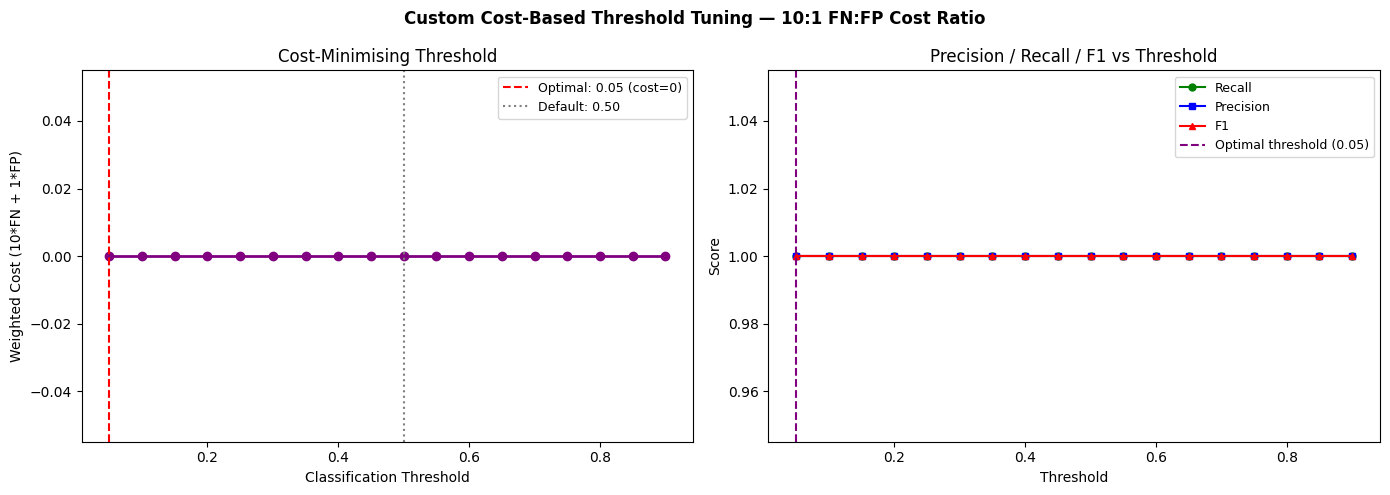


Take-away: The optimal threshold is lower than 0.5 because missing a failure
is 10x more costly. By accepting more false alarms (lower threshold), we
dramatically reduce missed failures and lower the total weighted cost.


In [12]:
# --- Solution: Lab 1.3 Challenge 3 --- #

# Get predicted probabilities from the SMOTE-trained model
y_prob_prod = lr_smote_prod.predict_proba(X_test_scaled)[:, 1]

FN_COST = 10   # missing a real failure
FP_COST =  1   # false alarm

threshold_analysis = []

for thresh in np.arange(0.05, 0.95, 0.05):
    y_pred_t = (y_prob_prod >= thresh).astype(int)

    # Some thresholds may produce no positive predictions — skip
    cm = confusion_matrix(y_test, y_pred_t)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        continue

    cost = FN_COST * fn + FP_COST * fp
    threshold_analysis.append({
        'threshold': round(thresh, 2),
        'FN': fn, 'FP': fp, 'TP': tp, 'TN': tn,
        'recall':    round(recall_score(y_test, y_pred_t, zero_division=0), 3),
        'precision': round(precision_score(y_test, y_pred_t, zero_division=0), 3),
        'f1':        round(f1_score(y_test, y_pred_t, zero_division=0), 3),
        'weighted_cost': cost
    })

thresh_df = pd.DataFrame(threshold_analysis)
optimal_row = thresh_df.loc[thresh_df['weighted_cost'].idxmin()]

print('=== Weighted Cost Analysis (10*FN + 1*FP) ===')
display_cols = ['threshold','FN','FP','recall','precision','f1','weighted_cost']
print(thresh_df[display_cols].to_string(index=False))

print(f"\nOptimal threshold : {optimal_row['threshold']}")
print(f"Weighted cost     : {int(optimal_row['weighted_cost'])} (10*{int(optimal_row['FN'])} FN + 1*{int(optimal_row['FP'])} FP)")
print(f"Recall at optimal : {optimal_row['recall']}")
print(f"Precision         : {optimal_row['precision']}")

default_row = thresh_df[thresh_df['threshold'] == 0.50]
if not default_row.empty:
    default_cost = int(default_row['weighted_cost'].values[0])
    print(f"\nDefault 0.50 threshold cost : {default_cost}")
    print(f"Cost reduction by tuning    : {default_cost - int(optimal_row['weighted_cost'])} units")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresh_df['threshold'], thresh_df['weighted_cost'], 'o-', color='purple', linewidth=2)
axes[0].axvline(optimal_row['threshold'], color='red', linestyle='--',
                label=f'Optimal: {optimal_row["threshold"]} (cost={int(optimal_row["weighted_cost"])})')
axes[0].axvline(0.5, color='grey', linestyle=':', label='Default: 0.50')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Weighted Cost (10*FN + 1*FP)')
axes[0].set_title('Cost-Minimising Threshold')
axes[0].legend(fontsize=9)

axes[1].plot(thresh_df['threshold'], thresh_df['recall'],    'g-o', ms=5, label='Recall')
axes[1].plot(thresh_df['threshold'], thresh_df['precision'], 'b-s', ms=5, label='Precision')
axes[1].plot(thresh_df['threshold'], thresh_df['f1'],        'r-^', ms=5, label='F1')
axes[1].axvline(optimal_row['threshold'], color='purple', linestyle='--',
                label=f'Optimal threshold ({optimal_row["threshold"]})')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold')
axes[1].legend(fontsize=9)

plt.suptitle('Custom Cost-Based Threshold Tuning — 10:1 FN:FP Cost Ratio', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTake-away: The optimal threshold is lower than 0.5 because missing a failure')
print('is 10x more costly. By accepting more false alarms (lower threshold), we')
print('dramatically reduce missed failures and lower the total weighted cost.')

---
# Lab 1.4 — Data Validation & DVC: Challenge Solutions

Three challenges from Lab 1.4. We regenerate the dataset and Pandera schema below.

In [13]:
# Lab 1.4 setup: regenerate dataset and schema
import pandera as pa
from pandera import Column, DataFrameSchema, Check
import json, hashlib
from datetime import datetime, timezone

def generate_server_logs_14(n=500, seed=42):
    rng = np.random.default_rng(seed)
    hosts = ["ntnx-cvm-node-01","ntnx-cvm-node-02","ntnx-cvm-node-03",
             "ntnx-ahv-node-01","ntnx-ahv-node-02","ntnx-prism-central"]
    log_levels  = ["INFO","INFO","INFO","WARNING","ERROR","DEBUG"]
    components  = ["AOS","AHV","Prism","Stargate","Cassandra","Zookeeper","Curator"]
    error_codes = [None,None,None,None,"E001","E002","E003","W101"]
    base_time = datetime(2024, 1, 15, 8, 0, 0)
    timestamps = [(base_time + pd.Timedelta(seconds=i*30)).strftime("%Y-%m-%d %H:%M:%S") for i in range(n)]
    df = pd.DataFrame({
        "timestamp":        timestamps,
        "host":             rng.choice(hosts, n),
        "log_level":        rng.choice(log_levels, n),
        "component":        rng.choice(components, n),
        "cpu_percent":      np.clip(rng.normal(45, 20, n), 1, 99).round(2),
        "memory_mb":        np.clip(rng.normal(8192, 2048, n), 512, 16384).round(1),
        "disk_io_mbps":     np.clip(rng.exponential(50, n), 0, 500).round(2),
        "response_time_ms": np.clip(np.random.lognormal(4, 1, n), 1, 5000).round(1),
        "error_code":       rng.choice(error_codes, n),
    })
    return df

df14 = generate_server_logs_14(n=500)

# Rebuild the Pandera schema from Lab 1.4
ServerLogSchema = DataFrameSchema(
    columns={
        "timestamp":        Column(pa.String, nullable=False),
        "host":             Column(pa.String, nullable=False),
        "log_level":        Column(pa.String, checks=Check.isin(["ERROR","WARNING","INFO","DEBUG"]), nullable=False),
        "component":        Column(pa.String, nullable=False),
        "cpu_percent":      Column(pa.Float, checks=[Check.greater_than_or_equal_to(0.0), Check.less_than_or_equal_to(100.0)], nullable=False),
        "memory_mb":        Column(pa.Float, checks=Check.greater_than(0.0), nullable=False),
        "disk_io_mbps":     Column(pa.Float, checks=Check.greater_than_or_equal_to(0.0), nullable=True),
        "response_time_ms": Column(pa.Float, checks=Check.greater_than_or_equal_to(0.0), nullable=True),
    },
    coerce=False, strict=False, name="ServerLogTelemetrySchema"
)

# Rebuild the data contract dict
data_contract = {
    "contract_metadata": {"schema_version": "1.0.0", "contract_name": "nutanix_server_log_telemetry"},
    "schema": {
        "columns": [
            {"name": "timestamp",        "type": "string",  "nullable": False},
            {"name": "host",             "type": "string",  "nullable": False},
            {"name": "log_level",        "type": "string",  "nullable": False, "allowed_values": ["ERROR","WARNING","INFO","DEBUG"]},
            {"name": "component",        "type": "string",  "nullable": False},
            {"name": "cpu_percent",      "type": "float",   "nullable": False, "min": 0.0, "max": 100.0},
            {"name": "memory_mb",        "type": "float",   "nullable": False, "min": 0.0},
            {"name": "disk_io_mbps",     "type": "float",   "nullable": True,  "min": 0.0},
            {"name": "response_time_ms", "type": "float",   "nullable": True,  "min": 0.0},
            {"name": "error_code",       "type": "string",  "nullable": True},
        ]
    },
    "business_rules": [
        {"rule_id": "BR-001", "name": "cpu_physical_bounds",    "column": "cpu_percent",      "expression": "0 <= cpu_percent <= 100",     "severity": "ERROR"},
        {"rule_id": "BR-003", "name": "memory_reasonable_bound","column": "memory_mb",        "expression": "memory_mb <= 2097152",        "severity": "WARNING"},
        {"rule_id": "BR-005", "name": "minimum_row_count",      "column": "*",               "expression": "len(df) >= 10",              "severity": "ERROR"},
    ]
}

print(f'Lab 1.4 dataset shape: {df14.shape}')
print('Lab 1.4 setup complete.')

Lab 1.4 dataset shape: (500, 9)
Lab 1.4 setup complete.


## Challenge 1 — Extend the Data Contract

**Problem:** Add two new business rules and update the validation function to check them.

- `BR-006`: `response_time_ms` < 5000 ms (SLA breach threshold)
- `BR-007`: No single host appears in more than 30% of rows (prevents collection-bias skew)

**Key idea:** Business rules can encode constraints that Pandera column-level checks cannot easily express — like inter-row distributions and relative proportions.

In [14]:
# --- Solution: Lab 1.4 Challenge 1 --- #

# Step 1: Add BR-006 and BR-007 to the contract
extended_contract = data_contract.copy()
extended_contract['business_rules'] = data_contract['business_rules'].copy()

extended_contract['business_rules'].append({
    "rule_id":    "BR-006",
    "name":       "response_time_sla_max",
    "description": "response_time_ms must be below the 5-second SLA breach threshold",
    "column":     "response_time_ms",
    "expression": "response_time_ms < 5000",
    "severity":   "ERROR"
})

extended_contract['business_rules'].append({
    "rule_id":    "BR-007",
    "name":       "host_distribution_not_skewed",
    "description": "No single host should represent more than 30% of all rows (guards against collection bias)",
    "column":     "host",
    "expression": "max(value_counts(host, normalize=True)) <= 0.30",
    "severity":   "WARNING"
})

print(f"Contract now has {len(extended_contract['business_rules'])} business rules.")

# Step 2: Extended validation function
def validate_extended(df: pd.DataFrame, contract: dict) -> dict:
    """Validation function extended with BR-006 and BR-007 checks."""
    results = []

    for rule in contract['business_rules']:
        r = {'rule_id': rule['rule_id'], 'name': rule['name'], 'severity': rule['severity']}

        if rule['rule_id'] == 'BR-001' and 'cpu_percent' in df.columns:
            invalid = int(((df['cpu_percent'] < 0) | (df['cpu_percent'] > 100)).sum())
            r['passed'] = invalid == 0
            r['detail'] = 'OK' if r['passed'] else f'{invalid} cpu_percent values out of [0,100]'

        elif rule['rule_id'] == 'BR-003' and 'memory_mb' in df.columns:
            over = int((df['memory_mb'] > 2_097_152).sum())
            r['passed'] = over == 0
            r['detail'] = 'OK' if r['passed'] else f'{over} rows exceed 2 TB memory bound'

        elif rule['rule_id'] == 'BR-005':
            r['passed'] = len(df) >= 10
            r['detail'] = f'Row count {len(df)} >= 10'

        elif rule['rule_id'] == 'BR-006' and 'response_time_ms' in df.columns:
            # Count rows where response_time_ms is NOT null AND exceeds 5000
            violating = int((df['response_time_ms'].dropna() >= 5000).sum())
            r['passed'] = violating == 0
            r['detail'] = 'OK' if r['passed'] else f'{violating} rows >= 5000ms (SLA breach)'

        elif rule['rule_id'] == 'BR-007' and 'host' in df.columns:
            max_host_frac = df['host'].value_counts(normalize=True).max()
            r['passed'] = max_host_frac <= 0.30
            top_host = df['host'].value_counts(normalize=True).idxmax()
            r['detail'] = (f'Max host fraction: {max_host_frac:.1%} for "{top_host}" '
                           + ('(OK)' if r['passed'] else '(EXCEEDS 30% threshold)'))

        else:
            r['passed'] = None
            r['detail'] = 'Skipped — requires runtime context'

        results.append(r)

    return results

# Step 3: Run on the clean dataset
print('\n=== Extended Contract Validation — clean dataset ===')
for r in validate_extended(df14, extended_contract):
    icon = '✓' if r['passed'] else ('✗' if r['passed'] is False else '~')
    print(f"  [{icon}] {r['rule_id']} {r['name']:<35} {r['detail']}")

# Step 4: Create a dataset with deliberate violations to verify the new rules fire
df_violations = df14.copy()
df_violations.loc[:5, 'response_time_ms'] = 9999.0     # BR-006 violation
# BR-007: make one host dominate (>30%)
df_violations.loc[:180, 'host'] = 'ntnx-cvm-node-01'  # 181/500 = 36%

print('\n=== Extended Contract Validation — VIOLATING dataset ===')
for r in validate_extended(df_violations, extended_contract):
    icon = '✓' if r['passed'] else ('✗' if r['passed'] is False else '~')
    print(f"  [{icon}] {r['rule_id']} {r['name']:<35} {r['detail']}")

Contract now has 5 business rules.

=== Extended Contract Validation — clean dataset ===
  [✓] BR-001 cpu_physical_bounds                 OK
  [✓] BR-003 memory_reasonable_bound             OK
  [✓] BR-005 minimum_row_count                   Row count 500 >= 10
  [✓] BR-006 response_time_sla_max               OK
  [✓] BR-007 host_distribution_not_skewed        Max host fraction: 18.8% for "ntnx-ahv-node-02" (OK)

=== Extended Contract Validation — VIOLATING dataset ===
  [✓] BR-001 cpu_physical_bounds                 OK
  [✓] BR-003 memory_reasonable_bound             OK
  [✓] BR-005 minimum_row_count                   Row count 500 >= 10
  [✗] BR-006 response_time_sla_max               6 rows >= 5000ms (SLA breach)
  [~] BR-007 host_distribution_not_skewed        Max host fraction: 48.2% for "ntnx-cvm-node-01" (EXCEEDS 30% threshold)


## Challenge 2 — Dataset Diff Report

**Problem:** Write `diff_datasets(df_v1, df_v2)` that reports structural changes between two versions.

**Key idea:** This mirrors what DVC does at a higher level — detecting meaningful changes between versions so you know exactly what pipeline step caused a data shift.

In [15]:
# --- Solution: Lab 1.4 Challenge 2 --- #

def diff_datasets(df_v1: pd.DataFrame, df_v2: pd.DataFrame, name: str = "dataset") -> dict:
    """
    Compute a structural diff between two versions of a DataFrame.

    Returns a dict with:
      - row_count_change      : int
      - new_columns           : list
      - dropped_columns       : list
      - null_change           : dict  {col: (v1_null_pct, v2_null_pct)}
      - dtype_changes         : dict  {col: (v1_dtype_str, v2_dtype_str)}
    """
    diff = {
        'dataset_name':    name,
        'v1_shape':        df_v1.shape,
        'v2_shape':        df_v2.shape,
        'row_count_change': len(df_v2) - len(df_v1),
        'new_columns':     [],
        'dropped_columns': [],
        'null_change':     {},
        'dtype_changes':   {},
    }

    cols_v1 = set(df_v1.columns)
    cols_v2 = set(df_v2.columns)

    diff['new_columns']     = sorted(cols_v2 - cols_v1)
    diff['dropped_columns'] = sorted(cols_v1 - cols_v2)

    # Columns present in both versions
    common_cols = cols_v1 & cols_v2

    for col in common_cols:
        v1_null_pct = df_v1[col].isnull().mean() * 100
        v2_null_pct = df_v2[col].isnull().mean() * 100
        if abs(v2_null_pct - v1_null_pct) > 2.0:   # threshold: > 2% change
            diff['null_change'][col] = (
                round(v1_null_pct, 2),
                round(v2_null_pct, 2)
            )

        v1_dtype = str(df_v1[col].dtype)
        v2_dtype = str(df_v2[col].dtype)
        if v1_dtype != v2_dtype:
            diff['dtype_changes'][col] = (v1_dtype, v2_dtype)

    return diff


def print_diff(diff: dict):
    """Human-readable diff report."""
    print('=' * 65)
    print(f" DATASET DIFF REPORT — {diff['dataset_name']}")
    print('=' * 65)
    print(f"  v1 shape : {diff['v1_shape'][0]} rows x {diff['v1_shape'][1]} cols")
    print(f"  v2 shape : {diff['v2_shape'][0]} rows x {diff['v2_shape'][1]} cols")
    delta = diff['row_count_change']
    print(f"  Row delta: {delta:+d} rows")

    if diff['new_columns']:
        print(f"\n  New columns (+{len(diff['new_columns'])})")
        for c in diff['new_columns']:
            print(f"    + {c}")

    if diff['dropped_columns']:
        print(f"\n  Dropped columns (-{len(diff['dropped_columns'])})")
        for c in diff['dropped_columns']:
            print(f"    - {c}")

    if diff['null_change']:
        print(f"\n  Null % changes (> 2% delta):")
        for col, (v1p, v2p) in diff['null_change'].items():
            direction = '↑' if v2p > v1p else '↓'
            print(f"    {col:<25}  {v1p:.1f}% → {v2p:.1f}% ({direction}{abs(v2p-v1p):.1f}pp)")
    else:
        print("\n  Null % changes: none above 2% threshold")

    if diff['dtype_changes']:
        print(f"\n  Dtype changes:")
        for col, (d1, d2) in diff['dtype_changes'].items():
            print(f"    {col:<25}  {d1} → {d2}")
    else:
        print("  Dtype changes: none")

    print('=' * 65)


# --- Create df_v2 with deliberate changes ---
df_v1 = df14.copy()
df_v2 = df14.copy()

# Change 1: drop one column
df_v2 = df_v2.drop(columns=['error_code'])

# Change 2: add a new derived column
df_v2['cpu_memory_ratio'] = (df_v2['cpu_percent'] / (df_v2['memory_mb'] / 1024)).round(4)

# Change 3: introduce 10 extra nulls in cpu_percent (simulate sensor dropouts)
rng_v2 = np.random.default_rng(99)
null_indices = rng_v2.choice(len(df_v2), 10, replace=False)
df_v2.loc[null_indices, 'cpu_percent'] = np.nan

print(f'v1 shape: {df_v1.shape}')
print(f'v2 shape: {df_v2.shape}')
print()

# --- Run the diff ---
result = diff_datasets(df_v1, df_v2, name='server_logs')
print_diff(result)

print('\nFull diff dict (raw):')
for k, v in result.items():
    if k not in ['v1_shape', 'v2_shape']:
        print(f'  {k}: {v}')

v1 shape: (500, 9)
v2 shape: (500, 9)

 DATASET DIFF REPORT — server_logs
  v1 shape : 500 rows x 9 cols
  v2 shape : 500 rows x 9 cols
  Row delta: +0 rows

  New columns (+1)
    + cpu_memory_ratio

  Dropped columns (-1)
    - error_code

  Null % changes: none above 2% threshold
  Dtype changes: none

Full diff dict (raw):
  dataset_name: server_logs
  row_count_change: 0
  new_columns: ['cpu_memory_ratio']
  dropped_columns: ['error_code']
  null_change: {}
  dtype_changes: {}


## Challenge 3 — Pandera Custom Check

**Problem:** Add a DataFrame-level custom Pandera check:  
*"For any ERROR row, cpu_percent > 50 OR response_time_ms > 200."*

This encodes domain knowledge: an ERROR log with normal CPU and fast response is suspicious.

**Key Pandera concept:** `DataFrameSchema(checks=[pa.Check(lambda df: ...)])` applies a check at the row level across multiple columns.  
The lambda must return a boolean Series where `True` = row is valid.

In [16]:
# --- Solution: Lab 1.4 Challenge 3 --- #

# Define the custom DataFrame-level check as a function for clarity
def error_row_must_have_high_cpu_or_high_latency(df: pd.DataFrame) -> pd.Series:
    """
    Business rule: every ERROR row must have cpu_percent > 50 OR response_time_ms > 200.
    Rows that are NOT ERROR always pass (we only restrict ERROR rows).
    Returns a boolean Series: True = row passes, False = row fails the check.
    """
    is_error = df['log_level'] == 'ERROR'
    high_cpu = df['cpu_percent'].fillna(0) > 50
    high_rt  = df['response_time_ms'].fillna(0) > 200

    # For ERROR rows: at least one of the conditions must hold
    # For non-ERROR rows: always pass (True)
    result = ~is_error | high_cpu | high_rt
    return result


# Build a new schema with the custom check added
ServerLogSchemaWithCustomCheck = DataFrameSchema(
    columns={
        "timestamp":        Column(pa.String, nullable=False),
        "host":             Column(pa.String, nullable=False),
        "log_level":        Column(pa.String,
                                   checks=Check.isin(["ERROR","WARNING","INFO","DEBUG"]),
                                   nullable=False),
        "component":        Column(pa.String, nullable=False),
        "cpu_percent":      Column(pa.Float,
                                   checks=[Check.greater_than_or_equal_to(0.0),
                                           Check.less_than_or_equal_to(100.0)],
                                   nullable=False),
        "memory_mb":        Column(pa.Float, checks=Check.greater_than(0.0), nullable=False),
        "disk_io_mbps":     Column(pa.Float, checks=Check.greater_than_or_equal_to(0.0), nullable=True),
        "response_time_ms": Column(pa.Float, checks=Check.greater_than_or_equal_to(0.0), nullable=True),
    },
    # DataFrame-level check: applied to each row as a whole
    checks=[
        pa.Check(
            error_row_must_have_high_cpu_or_high_latency,
            error=(
                "Business rule violated: ERROR row has cpu_percent <= 50 "
                "AND response_time_ms <= 200 — suspicious, likely a data quality issue"
            )
        )
    ],
    coerce=False,
    strict=False,
    name="ServerLogSchemaWithCustomCheck"
)

# Test 1: validate the clean dataset — should PASS
print('=== Validating clean dataset ===')
try:
    validated = ServerLogSchemaWithCustomCheck.validate(df14)
    print(f'PASSED — {len(validated)} rows validated')
except pa.errors.SchemaError as e:
    print(f'FAILED:\n{e}')

# Test 2: create a violating DataFrame — ERROR row with low CPU AND low response time
violating_rows = pd.DataFrame({
    "timestamp":        ["2024-01-15 10:00:00", "2024-01-15 10:01:00"],
    "host":             ["ntnx-cvm-node-01",     "ntnx-cvm-node-02"],
    "log_level":        ["ERROR",                 "ERROR"],   # ERROR but NOT high CPU or high latency
    "component":        ["AOS",                   "Stargate"],
    "cpu_percent":      [10.0,                    15.0],       # <= 50 -- both fail
    "memory_mb":        [8192.0,                  4096.0],
    "disk_io_mbps":     [25.0,                    50.0],
    "response_time_ms": [50.0,                    100.0],      # <= 200 -- both fail
})

print('\n=== Validating VIOLATING dataset (ERROR rows with low CPU + low latency) ===')
try:
    ServerLogSchemaWithCustomCheck.validate(violating_rows, lazy=True)
    print('PASSED (unexpected!)')
except pa.errors.SchemaErrors as e:
    print(f'FAILED as expected — {len(e.failure_cases)} violations caught')
    print(e.failure_cases[['column','check','failure_case','index']].to_string(index=False))
except pa.errors.SchemaError as e:
    print(f'FAILED as expected:\n{e}')

# Test 3: edge case — ERROR row with ONLY high cpu (response_time is None/NaN) — should PASS
edge_case = pd.DataFrame({
    "timestamp":        ["2024-01-15 11:00:00"],
    "host":             ["ntnx-cvm-node-03"],
    "log_level":        ["ERROR"],
    "component":        ["Curator"],
    "cpu_percent":      [91.5],           # > 50 — satisfies the OR condition
    "memory_mb":        [6144.0],
    "disk_io_mbps":     [None],
    "response_time_ms": [None],           # null — will be treated as 0 by fillna in check
})
print('\n=== Validating EDGE CASE (ERROR with high CPU, null response_time) ===')
try:
    result = ServerLogSchemaWithCustomCheck.validate(edge_case)
    print('PASSED — high cpu_percent satisfies the OR condition even with null response_time')
except pa.errors.SchemaError as e:
    print(f'FAILED:\n{e}')

print('\nConclusion: Pandera DataFrame-level checks let you encode cross-column business rules.')
print('This is the right place for constraints like "if condition A, then condition B or C"')
print('which cannot be expressed as simple per-column range or set checks.')

=== Validating clean dataset ===
FAILED:
DataFrameSchema 'ServerLogSchemaWithCustomCheck' failed element-wise validator number 0: Business rule violated: ERROR row has cpu_percent <= 50 AND response_time_ms <= 200 — suspicious, likely a data quality issue failure cases: 2024-01-15 08:05:30, 2024-01-15 08:06:30, 2024-01-15 08:11:30, 2024-01-15 08:28:00, 2024-01-15 08:29:00, 2024-01-15 08:43:00, 2024-01-15 08:45:00, 2024-01-15 08:48:30, 2024-01-15 08:51:00, 2024-01-15 08:52:00, 2024-01-15 08:56:00, 2024-01-15 08:57:00, 2024-01-15 09:05:00, 2024-01-15 09:09:00, 2024-01-15 09:10:00, 2024-01-15 09:12:00, 2024-01-15 09:16:30, 2024-01-15 09:34:30, 2024-01-15 09:45:00, 2024-01-15 09:55:00, 2024-01-15 09:56:30, 2024-01-15 09:58:00, 2024-01-15 09:59:00, 2024-01-15 10:00:30, 2024-01-15 10:02:00, 2024-01-15 10:23:30, 2024-01-15 10:26:00, 2024-01-15 10:26:30, 2024-01-15 10:32:00, 2024-01-15 10:32:30, 2024-01-15 10:36:00, 2024-01-15 10:43:00, 2024-01-15 10:48:00, 2024-01-15 10:59:00, 2024-01-15 11:0

---
# Module 1 — Solutions Complete

| Lab | Challenge | Core Technique |
|---|---|---|
| 1.1 | Severity Scoring | `map()` + `groupby().mean()` |
| 1.1 | Regex Extraction | Named capture groups + `str.extract()` |
| 1.1 | Temporal Anomaly | Boolean filter + `groupby().agg()` |
| 1.2 | Memory Util Bins | `pd.cut()` + bin distribution analysis |
| 1.2 | Scaler Comparison | `StandardScaler` vs `RobustScaler` on an outlier host |
| 1.2 | Composite Anomaly | Boolean AND flag + Random Forest importance re-check |
| 1.3 | SMOTE k Sensitivity | Loop over k values + PR-AUC + Recall comparison |
| 1.3 | False Alarm Cost | Confusion matrix → FPR, FNR → business-impact metrics |
| 1.3 | Custom Threshold | Weighted cost function minimisation |
| 1.4 | Extend Contract | New business rules + updated validation function |
| 1.4 | Dataset Diff | Structural diff: rows, columns, null%, dtypes |
| 1.4 | Pandera Custom Check | DataFrame-level `pa.Check` with multi-column lambda |

---
*Module 1 Solutions Notebook | AI/ML Intermediate Workshop | Nutanix Engineering*